# Ficheiro 2 - Morbilidade e Mortalidade Hospitalar


## Análise da Demora Média por Diagnóstico e Faixa Etária
User story 3:
"Como responsável clínico, quero ver a demora média por diagnóstico, faixa etária, sexo e especialidade, para perceber que perfil de doente ocupa mais dias de internamento.

In [1]:
import sqlite3
import pandas as pd

df = pd.read_csv("../data/processed/morbilidade_mortalidade_tratado.csv", sep=",", encoding="utf-8-sig")


# Liga (ou cria) a base de dados SQLite
con = sqlite3.connect("../data/processed/morbilidade-hospital.db")

# df.to_sql escreve o DataFrame como uma TABELA dentro da base de dados.
# if_exists='replace' substitui a tabela se já existir; index=False não guarda o nº da linha.

df.to_sql("morbilidade", con, if_exists="replace", index=False)


q_diag = """
SELECT 
    descricao_diagnostico_principal,
    (SUM(dias_internamentos) * 1.0 / SUM(internamentos)) AS demora_media
FROM morbilidade
WHERE internamentos > 0
GROUP BY 
    descricao_diagnostico_principal
ORDER BY demora_media DESC;
"""
print("Demora média por diagnóstico:")
display(pd.read_sql(q_diag, con))



q = """

SELECT 

    faixa_etaria,        
    (SUM(dias_internamentos) * 1.0 / SUM(internamentos)) AS demora_media
FROM morbilidade
WHERE internamentos > 0 
GROUP BY faixa_etaria
ORDER BY demora_media DESC;
"""
print(" ")
print("Demora média por faixa etária:")
display(pd.read_sql(q, con))

Demora média por diagnóstico:


,descricao_diagnostico_principal,demora_media
0,"Transtornos mentais, comportamentais e de neur...",23.537368
1,Algumas doenças infecciosas e parasitárias,13.090277
2,Códigos para fins especiais,12.385789
3,"Lesões, envenenamento e algumas outras consequ...",11.748014
4,Doenças do sistema nervoso,11.379726
5,Doenças da pele e do tecido subcutâneo,10.567981
6,Doenças do aparelho circulatório,10.085870
7,Doenças do sangue e dos órgãos hematopoéticos ...,9.842610
8,Doenças do aparelho respiratório,9.106446
9,Neoplasias,8.797165


 
Demora média por faixa etária:


,faixa_etaria,demora_media
0,[65-120[,10.579033
1,[45-65[,8.560548
2,[15-25[,5.531895
3,[25-45[,5.357197
4,[5-15[,4.982181
5,[1-5[,4.540178
6,[0-1[,4.140191


## Conclusão

A análise da demora média por diagnóstico revela que os internamentos mais prolongados estão associados principalmente a transtornos mentais, comportamentais e de neurodesenvolvimento, com uma média de 23 dias por internamento. Seguem-se as doenças infeciosas e parasitárias e códigos para fins especiais, ambos com valores superiores a 12 dias. Estes resultados sugerem que determinadas áreas clínicas apresentam maior complexidade ou necessidade de acompanhamento prolongado, refletindo-se em períodos mais longos de internamento.

A faixa etária dos 65-120 anos apresenta a maior demora média de internamento, seguida da faixa dos 45-65 anos. As restantes faixas etárias apresentam demoras médias entre 4 e 5 dias. Estes resultados sugerem que os doentes mais idosos têm internamentos de maior duração, o que poderá estar relacionado com uma maior complexidade clínica e com processos de recuperação mais prolongados.


## Análise da Demora Média por Sexo
User story 3:
"Como responsável clínico, quero ver a demora média por diagnóstico, faixa etária, sexo e especialidade, para perceber que perfil de doente ocupa mais dias de internamento."

Demora média por sexo:
      dias_internamentos  internamentos  demora_media
sexo                                                 
F               22266771        2896456      7.687592
I                    218             21     10.380952
M               22725369        2478269      9.169856

Total de internamentos por sexo:
sexo
F    2896456
I         21
M    2478269
Name: internamentos, dtype: int64


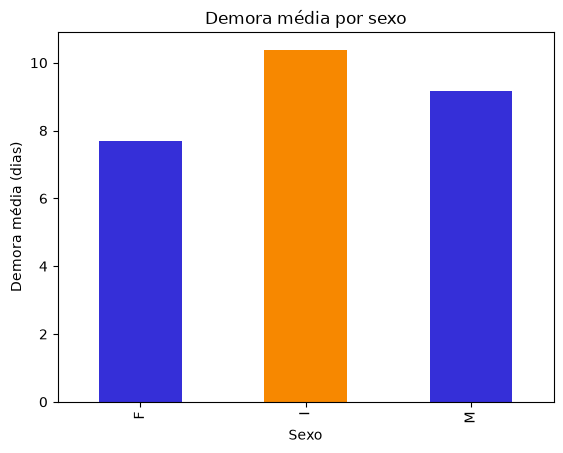

In [2]:
print("Demora média por sexo:")
demora_sexo = df.groupby("sexo")[
    ["dias_internamentos", "internamentos"]
].sum()

demora_sexo["demora_media"] = (
    demora_sexo["dias_internamentos"] /
    demora_sexo["internamentos"]
)

print(demora_sexo)


demora_sexo["demora_media"].plot(kind="bar", title="Demora média por sexo", xlabel="Sexo", ylabel="Demora média (dias)", color=["#352fd8", "#f78800"])


print("")
print("Total de internamentos por sexo:")
print(df.groupby("sexo")["internamentos"].sum())


## Conclusão:
 O grupo classificado como "Indeterminado" apresenta a maior demora média, no entanto, é referente a apenas 21 internamentos, sendo uma amostra demasiado reduzida para condicionar o resultado. Assim, a comparação mais fiável é entre os sexos feminino e masculino, verificando-se uma maior duração média dos internamentos nos doentes do sexo masculino.